### One regression endpoint

In [1]:
import scarse

scarse.train(data_path="./tutorial_data/train.csv", 
             classification=False, 
             seq_col="sequence",
             score_col=["score"])

/Users/leoan/Documents/GitHub/scarse/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 566/566 [00:00<00:00, 8326.23it/s]
EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly init

{'score': {'MSE': 0.5514294623447118,
  'RMSE': 0.7425829666405713,
  'MAE': 0.5835692278689905,
  'R2': 0.6359185257307869,
  'Spearman correlation': 0.8051605160516051}}

In [2]:
df_pred = scarse.pred(data_path="./tutorial_data/test.csv",
                      seq_col="sequence")

In [3]:
df_pred

,sequence,pred_score
0,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASTPDAQRYN...,-1.609579
1,ALRDDEYDEWQDIIRDWRKEWTVQQGLDLKERALSGASDPDSQRYN...,-3.857777
2,ALRDDEYDEWQDIIHAWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-1.112921
3,ALRDDEYDEWQDIIRDWRKEDTVQQILDLKERALSGASDPDSQRYN...,-3.928836
4,ALRDDEYDEWQDIIRGWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-1.513499
...,...,...
495,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASKPDWQRYN...,-2.671332
496,ALRDDEYDEWQDIIRGWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-1.604898
497,ALRDDEYDEWQDIIPDWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-3.520424
498,ALRDDEYDEWQDIIISWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-1.070108


### Visualize predictions

In [4]:
%pip install matplotlib

  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 41.3 MB/s eta 0:00:0000:01
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-macosx_11_0_arm64.whl (64 kB)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Merged rows: 500
R²: 0.695403398327394


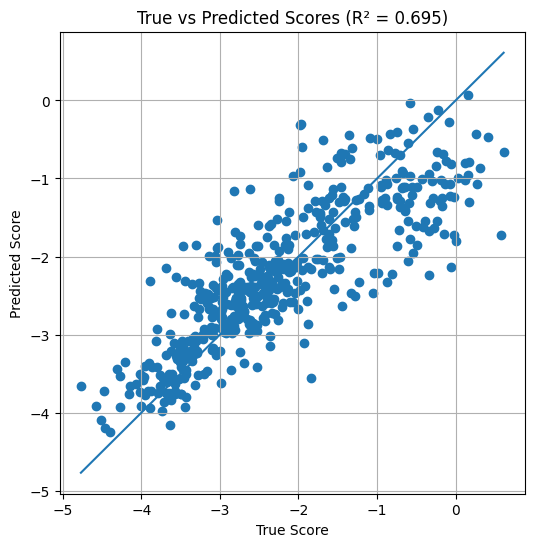

In [5]:
import pandas as pd
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# ----- Load data -----
# Adjust file paths as needed
df_true = pd.read_csv("./tutorial_data/test.csv", sep=",")     


# ----- Merge on peptide sequence -----
df = pd.merge(df_true, df_pred, on="sequence", how="inner")

print("Merged rows:", len(df))

# ----- Compute R² -----
y_true = df["score"]
y_pred = df["pred_score"]

r2 = r2_score(y_true, y_pred)
print("R²:", r2)

# ----- Scatter plot -----
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred)
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title(f"True vs Predicted Scores (R² = {r2:.3f})")
plt.grid(True)

# Add y=x line for reference
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

### Two regression endpoint

In [4]:
import scarse

scarse.train(data_path="./tutorial_data/train.csv", 
             classification=False, 
             seq_col="sequence",
             score_col=["score", "score_2"])

Loading weights: 100%|██████████| 566/566 [00:00<00:00, 20233.15it/s]
EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Best trial: 83. Best value: 0.594722: 100%|██████████| 100/100 [00:21<00:00,  4.68it/s]


{'score': {'MSE': 0.5514294623447118,
  'RMSE': 0.7425829666405713,
  'MAE': 0.5835692278689905,
  'R2': 0.6359185257307869,
  'Spearman correlation': 0.8051605160516051},
 'score_2': {'MSE': 0.5947222787247909,
  'RMSE': 0.7711823900510117,
  'MAE': 0.6023455149049624,
  'R2': 0.6195859799438084,
  'Spearman correlation': 0.8064326432643264}}

In [5]:
df_pred = scarse.pred(data_path="./tutorial_data/test.csv",
                      seq_col="sequence")
df_pred

,sequence,pred_score,pred_score_2
0,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASTPDAQRYN...,-1.609579,-1.574252
1,ALRDDEYDEWQDIIRDWRKEWTVQQGLDLKERALSGASDPDSQRYN...,-3.857777,-3.898414
2,ALRDDEYDEWQDIIHAWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-1.112921,-1.082579
3,ALRDDEYDEWQDIIRDWRKEDTVQQILDLKERALSGASDPDSQRYN...,-3.928836,-4.053114
4,ALRDDEYDEWQDIIRGWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-1.513499,-1.588036
...,...,...,...
495,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASKPDWQRYN...,-2.671332,-2.655759
496,ALRDDEYDEWQDIIRGWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-1.604898,-1.605408
497,ALRDDEYDEWQDIIPDWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-3.520424,-3.522891
498,ALRDDEYDEWQDIIISWRKEMTVQQFLDLKERALSGASDPDSQRYN...,-1.070108,-1.189098


Merged rows: 500
R² score: 0.695403398327394


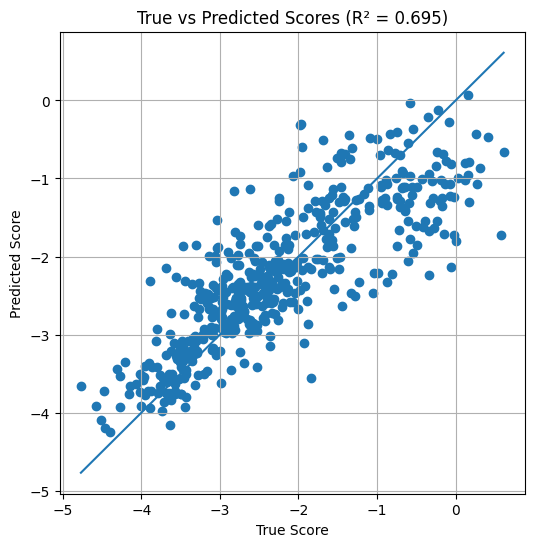

R² score_2: 0.6849481428800022


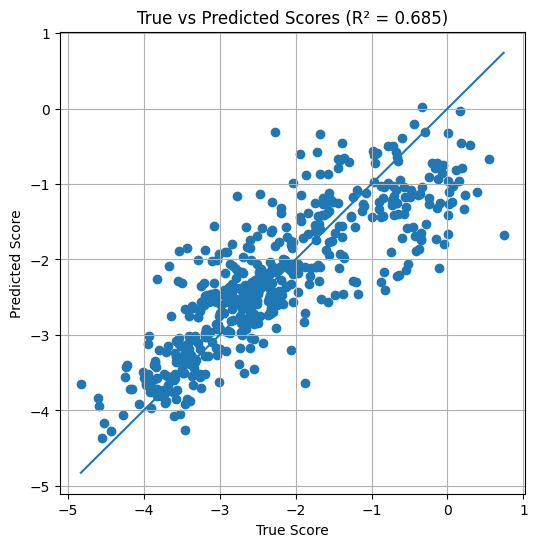

In [6]:
import pandas as pd
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# ----- Load data -----
# Adjust file paths as needed
df_true = pd.read_csv("./tutorial_data/test.csv", sep=",")     


# ----- Merge on peptide sequence -----
df = pd.merge(df_true, df_pred, on="sequence", how="inner")

print("Merged rows:", len(df))

# ----- Compute R² -----
y_true = df["score"]
y_pred = df["pred_score"]

r2 = r2_score(y_true, y_pred)
print("R² score:", r2)

# ----- Scatter plot -----
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred)
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title(f"True vs Predicted Scores (R² = {r2:.3f})")
plt.grid(True)

# Add y=x line for reference
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()


# ----- Compute R² -----
y_true = df["score_2"]
y_pred = df["pred_score_2"]

r2 = r2_score(y_true, y_pred)
print("R² score_2:", r2)

# ----- Scatter plot -----
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred)
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title(f"True vs Predicted Scores (R² = {r2:.3f})")
plt.grid(True)

# Add y=x line for reference
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

### One classification endpoint

In [9]:
import scarse

scarse.train(data_path="./tutorial_data/train.csv", 
             classification=True, 
             seq_col="sequence",
             score_col=["score_binary_class"])

Finished preparing data!
Loading base pretrained ESM model: facebook/esm2_t33_650M_UR50D


Loading weights: 100%|██████████| 566/566 [00:00<00:00, 22530.97it/s]
EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM model loaded. Using device: cpu

Optimizing models for target score_binary_class 1/1...


Best trial: 54. Best value: 0.468931: 100%|██████████| 100/100 [05:47<00:00,  3.48s/it]


{'score_binary_class': {'Accuracy': 0.79,
  'Balanced_Accuracy': 0.79,
  'F1_weighted': 0.7898108297467721,
  'MCC': 0.5810468272831243,
  'ROC_AUC': 0.8635999999999999}}

In [10]:
df_pred = scarse.pred(data_path="./tutorial_data/test.csv",
                      seq_col="sequence")
df_pred

,sequence,pred_score_binary_class,pred_encoded_score_binary_class,prob_score_binary_class_0,prob_score_binary_class_1
0,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASTPDAQRYN...,high,0,0.744862,0.255138
1,ALRDDEYDEWQDIIRDWRKEWTVQQGLDLKERALSGASDPDSQRYN...,low,1,0.037438,0.962562
2,ALRDDEYDEWQDIIHAWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.885198,0.114802
3,ALRDDEYDEWQDIIRDWRKEDTVQQILDLKERALSGASDPDSQRYN...,low,1,0.078816,0.921184
4,ALRDDEYDEWQDIIRGWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.931877,0.068123
...,...,...,...,...,...
495,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASKPDWQRYN...,low,1,0.263599,0.736401
496,ALRDDEYDEWQDIIRGWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.862697,0.137303
497,ALRDDEYDEWQDIIPDWRKEMTVQQFLDLKERALSGASDPDSQRYN...,low,1,0.157586,0.842414
498,ALRDDEYDEWQDIIISWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.901864,0.098136


In [11]:
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# ----- Load data -----
# Adjust file paths as needed
df_true = pd.read_csv("./tutorial_data/test.csv", sep=",")  


# ----- Merge on peptide sequence -----
df = pd.merge(df_true, df_pred, on="sequence", how="inner")

le = LabelEncoder()
df["score_binary_class"] = le.fit_transform(df["score_binary_class"].astype(str))

print("Merged rows:", len(df))

# ----- Compute R² -----
y_true = df["score_binary_class"]
y_pred = df["prob_score_binary_class_1"]

roc_auc = roc_auc_score(y_true, y_pred)
print("ROC AUC:", roc_auc)

Merged rows: 500
ROC AUC: 0.913926282051282


### Two classification endpoint

In [12]:
import scarse

scarse.train(data_path="./tutorial_data/train.csv", 
             classification=True, 
             seq_col="sequence",
             score_col=["score_binary_class", "score_binary_class_random"])

Finished preparing data!
Loading base pretrained ESM model: facebook/esm2_t33_650M_UR50D


Loading weights: 100%|██████████| 566/566 [00:00<00:00, 21377.93it/s]
EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM model loaded. Using device: cpu

Optimizing models for target score_binary_class 1/2...


Best trial: 54. Best value: 0.468931: 100%|██████████| 100/100 [05:40<00:00,  3.40s/it]



Optimizing models for target score_binary_class_random 2/2...


Best trial: 86. Best value: 0.70007: 100%|██████████| 100/100 [01:12<00:00,  1.39it/s]


{'score_binary_class': {'Accuracy': 0.79,
  'Balanced_Accuracy': 0.79,
  'F1_weighted': 0.7898108297467721,
  'MCC': 0.5810468272831243,
  'ROC_AUC': 0.8635999999999999},
 'score_binary_class_random': {'Accuracy': 0.46,
  'Balanced_Accuracy': 0.4519230769230769,
  'F1_weighted': 0.4375283732660782,
  'MCC': -0.10482848367219184,
  'ROC_AUC': 0.4915865384615385}}

In [13]:
df_pred = scarse.pred(data_path="./tutorial_data/test.csv",
                      seq_col="sequence")
df_pred

,sequence,pred_score_binary_class,pred_encoded_score_binary_class,prob_score_binary_class_0,prob_score_binary_class_1,pred_score_binary_class_random,pred_encoded_score_binary_class_random,prob_score_binary_class_random_0,prob_score_binary_class_random_1
0,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASTPDAQRYN...,high,0,0.739425,0.260575,low,1,0.450371,0.549629
1,ALRDDEYDEWQDIIRDWRKEWTVQQGLDLKERALSGASDPDSQRYN...,low,1,0.078253,0.921747,high,0,0.591442,0.408558
2,ALRDDEYDEWQDIIHAWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.920725,0.079275,low,1,0.457196,0.542804
3,ALRDDEYDEWQDIIRDWRKEDTVQQILDLKERALSGASDPDSQRYN...,low,1,0.074537,0.925463,high,0,0.526707,0.473293
4,ALRDDEYDEWQDIIRGWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.891759,0.108241,low,1,0.456563,0.543437
...,...,...,...,...,...,...,...,...,...
495,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASKPDWQRYN...,low,1,0.204350,0.795650,low,1,0.451450,0.548550
496,ALRDDEYDEWQDIIRGWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.881970,0.118030,low,1,0.445276,0.554724
497,ALRDDEYDEWQDIIPDWRKEMTVQQFLDLKERALSGASDPDSQRYN...,low,1,0.124531,0.875469,low,1,0.464548,0.535452
498,ALRDDEYDEWQDIIISWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.926505,0.073495,low,1,0.459271,0.540729


In [14]:
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# ----- Load data -----
df_true = pd.read_csv("./tutorial_data/test.csv", sep=",")  


# ----- Merge on peptide sequence -----
df = pd.merge(df_true, df_pred, on="sequence", how="inner")

le = LabelEncoder()
df["score_binary_class"] = le.fit_transform(df["score_binary_class"].astype(str))

print("Merged rows:", len(df))

# ----- Compute R² -----
y_true = df["score_binary_class"]
y_pred = df["prob_score_binary_class_1"]

roc_auc = roc_auc_score(y_true, y_pred)
print("ROC AUC score_binary_class:", roc_auc)

le = LabelEncoder()
df["score_binary_class_random"] = le.fit_transform(df["score_binary_class_random"].astype(str))

print("Merged rows:", len(df))

# ----- Compute R² -----
y_true = df["score_binary_class_random"]
y_pred = df["prob_score_binary_class_random_1"]

roc_auc = roc_auc_score(y_true, y_pred)
print("ROC AUC score_binary_class_random:", roc_auc)

Merged rows: 500
ROC AUC score_binary_class: 0.9060737179487179
Merged rows: 500
ROC AUC score_binary_class_random: 0.5151018572071203


### Multi class classification

In [15]:
import scarse

scarse.train(data_path="./tutorial_data/train.csv", 
             classification=True, 
             seq_col="sequence",
             score_col=["score_multi_class"])

Finished preparing data!
Loading base pretrained ESM model: facebook/esm2_t33_650M_UR50D


Loading weights: 100%|██████████| 566/566 [00:00<00:00, 23674.89it/s]
EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM model loaded. Using device: cpu

Optimizing models for target score_multi_class 1/1...


Best trial: 89. Best value: 0.684059: 100%|██████████| 100/100 [09:10<00:00,  5.50s/it]


{'score_multi_class': {'Accuracy': 0.68,
  'Balanced_Accuracy': 0.6536939863401633,
  'F1_weighted': 0.6758085290190843,
  'MCC': 0.48287995111400034,
  'ROC_AUC': 0.8312505804055099}}

In [16]:
df_pred = scarse.pred(data_path="./tutorial_data/test.csv",
                      seq_col="sequence")
df_pred

,sequence,pred_score_multi_class,pred_encoded_score_multi_class,prob_score_multi_class_0,prob_score_multi_class_1,prob_score_multi_class_2
0,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASTPDAQRYN...,high,0,0.604439,0.021823,0.373737
1,ALRDDEYDEWQDIIRDWRKEWTVQQGLDLKERALSGASDPDSQRYN...,low,1,0.064915,0.563166,0.371919
2,ALRDDEYDEWQDIIHAWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.683196,0.018895,0.297909
3,ALRDDEYDEWQDIIRDWRKEDTVQQILDLKERALSGASDPDSQRYN...,low,1,0.100091,0.723425,0.176484
4,ALRDDEYDEWQDIIRGWRKEMTVQQFLDLKERALSGASDPDSQRYN...,medium,2,0.274216,0.029665,0.696119
...,...,...,...,...,...,...
495,ALRDDEYDEWQDIIRDWRKEMTVQQFLDLKERALSGASKPDWQRYN...,medium,2,0.092883,0.048560,0.858557
496,ALRDDEYDEWQDIIRGWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.687712,0.026705,0.285584
497,ALRDDEYDEWQDIIPDWRKEMTVQQFLDLKERALSGASDPDSQRYN...,medium,2,0.121455,0.405675,0.472870
498,ALRDDEYDEWQDIIISWRKEMTVQQFLDLKERALSGASDPDSQRYN...,high,0,0.513812,0.067696,0.418491


In [17]:
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, label_binarize

# ----- Load data -----
df_true = pd.read_csv("./tutorial_data/test.csv", sep=",")     

# ----- Merge on peptide sequence -----
df = pd.merge(df_true, df_pred, on="sequence", how="inner")

le = LabelEncoder()
df["score_multi_class_enc"] = le.fit_transform(df["score_multi_class"].astype(str))

print("Merged rows:", len(df))

# ----- Compute R² -----
y_true = df["score_multi_class_enc"]
y_pred = df[["prob_score_multi_class_0", "prob_score_multi_class_1", "prob_score_multi_class_2"]]

y_test_bin = label_binarize(y_true, classes=le.transform(le.classes_))

roc_auc = roc_auc_score(
                        y_test_bin,
                        y_pred,
                        average="weighted",
                        multi_class="ovr"
                    )

print("ROC AUC:", roc_auc)

Merged rows: 500
ROC AUC: 0.8555943124707808
